In [1]:
from cocohirf.experiment.classification_experiment import HPOClassificationCoClusteringExperiment, HPOClassificationVeCoHiRFExperiment, ClassificationCoClusteringExperiment
from sklearn.datasets import make_classification
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
from ml_experiments.utils import unflatten_any, flatten_any, update_recursively
from cohirf.models.vecohirf import VeCoHiRF
from cocohirf.experiment.tested_models import two_stage_models_dict
import numpy as np
import matplotlib as mpl
from pathlib import Path
from copy import deepcopy

In [2]:
results_dir = Path("/home/belucci/code/cocohirf/results/hypercube")
results_dir.mkdir(parents=True, exist_ok=True)

In [3]:
n_samples: int | list[int] = 1000
n_random: int | list[int] = 10
n_informative: int | list[int] = 3
n_redundant: int = 0
n_repeated: int = 0
n_classes: int | list[int] = 5
class_sep: float | list[float] = 10*n_informative**0.5
seed_dataset: int = 42
shift: float | None = None
scale: float | None = None
X, y = make_classification(
    n_samples=n_samples,
    n_features=n_informative + n_redundant + n_repeated + n_random,
    n_informative=n_informative,
    n_redundant=n_redundant,
    n_repeated=n_repeated,
    n_classes=n_classes,
    class_sep=class_sep,
	shift=shift,
	scale=scale,
    random_state=seed_dataset,
	n_clusters_per_class=1,
	flip_y=0.0,
)
informative_features = list(range(n_informative))
random_features = list(range(n_informative + n_redundant + n_repeated, n_informative + n_redundant + n_repeated + n_random))
n_agents = 3
p_overlap = 0.0
sequential_split = False
n_trials = 50
n_trials_1 = n_trials
n_trials_2 = 30
hpo_metric = "adjusted_rand_mean"
direction = "maximize"
# equally split informative features among agents and distribute random features
features_groups = []
for agent_i in range(n_agents):
    agent_informative = informative_features[agent_i::n_agents]
    n_agent_informative = len(agent_informative)
    n_random_per_agent = len(random_features) // n_agents
    start_idx = agent_i * n_random_per_agent
    if agent_i == n_agents - 1:
        agent_random = random_features[start_idx:]
    else:
        agent_random = random_features[start_idx:start_idx + n_random_per_agent]
    features_groups.append(agent_informative + agent_random)

In [4]:
class_sep*2

34.64101615137754

In [5]:
features_groups

[[0, 3, 4, 5], [1, 6, 7, 8], [2, 9, 10, 11, 12]]

In [6]:
tsne = TSNE(n_components=2, random_state=seed_dataset)
X_embedded = tsne.fit_transform(X)

Text(0, 0.5, 't-SNE feature 2')

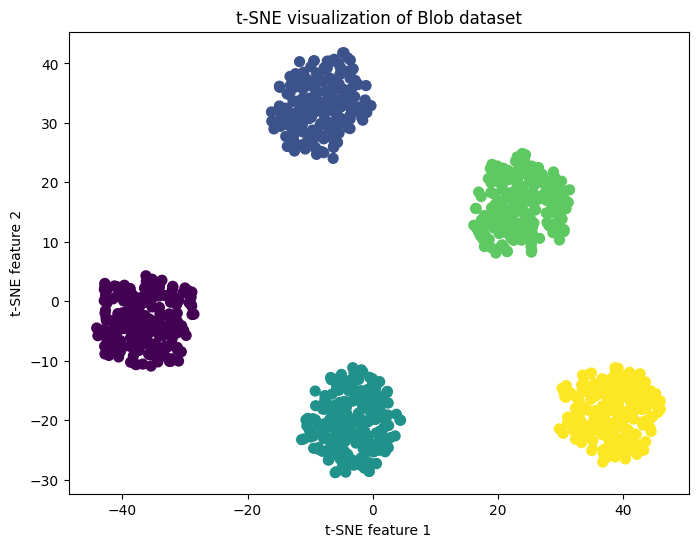

In [7]:
fig = plt.figure(figsize=(8, 6))
plt.scatter(X_embedded[:, 0], X_embedded[:, 1], c=y, cmap="viridis", s=50)
plt.title("t-SNE visualization of Blob dataset")
plt.xlabel("t-SNE feature 1")
plt.ylabel("t-SNE feature 2")

In [8]:
model = "VeCoHiRF-1iter"
hpo_experiment = HPOClassificationVeCoHiRFExperiment(
    # dataset
    n_samples=n_samples,
    n_informative=n_informative,
    n_random=n_random,
    n_redundant=n_redundant,
    n_repeated=n_repeated,
    n_classes=n_classes,
    class_sep=class_sep,
    seed_dataset=seed_dataset,
    shift=shift,
    scale=scale,
    n_agents=n_agents,
    p_overlap=p_overlap,
    sequential_split=sequential_split,
	features_groups=features_groups,
    # model
    model_alias=model,
    n_trials_1=n_trials_1,
    n_trials_2=n_trials_2,
    # seed_model=seed_dataset,
    # hpo
    hpo_seed=seed_dataset,
    hpo_metric_1=hpo_metric,
    hpo_metric_2=hpo_metric,
    direction_1=direction,
    direction_2=direction,
    calculate_metrics_even_if_too_many_clusters=True,
    # experiment
    raise_on_error=True,
    verbose=1,
)
hpo_result = hpo_experiment.run(return_results=True)[0]
ari = hpo_result["evaluate_model_return"]["best/adjusted_rand_mean"]
print(f"Best Adjusted Rand Index (ARI) from HPO: {ari}")

Combinations completed:   0%|          | 0/1 [00:00<?, ?it/s]

Trials:   0%|          | 0/50 [00:00<?, ?it/s]

Trials:   0%|          | 0/50 [00:00<?, ?it/s]

Trials:   0%|          | 0/50 [00:00<?, ?it/s]

Trials:   0%|          | 0/30 [00:00<?, ?it/s]

Best Adjusted Rand Index (ARI) from HPO: 1.0


In [9]:
vecohirf_model = deepcopy(two_stage_models_dict[model]["vecohirf_model"])
model_params = deepcopy(two_stage_models_dict[model]["vecohirf_params"])
best_params = deepcopy(hpo_result["fit_model_return"]["study"].best_params)
cohirf_kwargs = []
for best_trial_index, index in best_params.items():
    if best_trial_index.startswith("best_trial_index_"):
        agent_idx = int(best_trial_index.split("_")[-1])
        best_trial = deepcopy(hpo_result["fit_model_return"]["studies_1"][agent_idx].trials[index])
        best_model_params = deepcopy(best_trial.user_attrs["model_params"])
        best_model_params["random_state"] = best_trial.user_attrs["seed_model"]
        cohirf_kwargs.append(best_model_params)

# pop best_trial_index_* from best_params
best_params = {k: v for k, v in best_params.items() if not k.startswith("best_trial_index_")}
model_params = flatten_any(model_params)
model_params = update_recursively(model_params, best_params)
model_params = unflatten_any(model_params)
model_params["cohirf_kwargs"] = cohirf_kwargs

In [10]:
experiment = ClassificationCoClusteringExperiment(
    # dataset
    n_samples=n_samples,
    n_informative=n_informative,
    n_random=n_random,
    n_redundant=n_redundant,
    n_repeated=n_repeated,
    n_classes=n_classes,
    class_sep=class_sep,
    seed_dataset=seed_dataset,
    shift=shift,
    scale=scale,
    n_agents=n_agents,
    p_overlap=p_overlap,
    sequential_split=sequential_split,
    features_groups=features_groups,
	# model
	model=VeCoHiRF,
    model_params=model_params,
    # experiment
    raise_on_error=True,
    verbose=1,
)
result = experiment.run(return_results=True)[0]

Combinations completed:   0%|          | 0/1 [00:00<?, ?it/s]

In [11]:
features = result["load_data_return"]["X"]
y_true = result["load_data_return"]["y"]
labels = result["fit_model_return"]["y_pred"]
unique_labels = np.unique(labels)
tsne = TSNE(n_components=2, random_state=seed_dataset)
X_embedded = tsne.fit_transform(features)

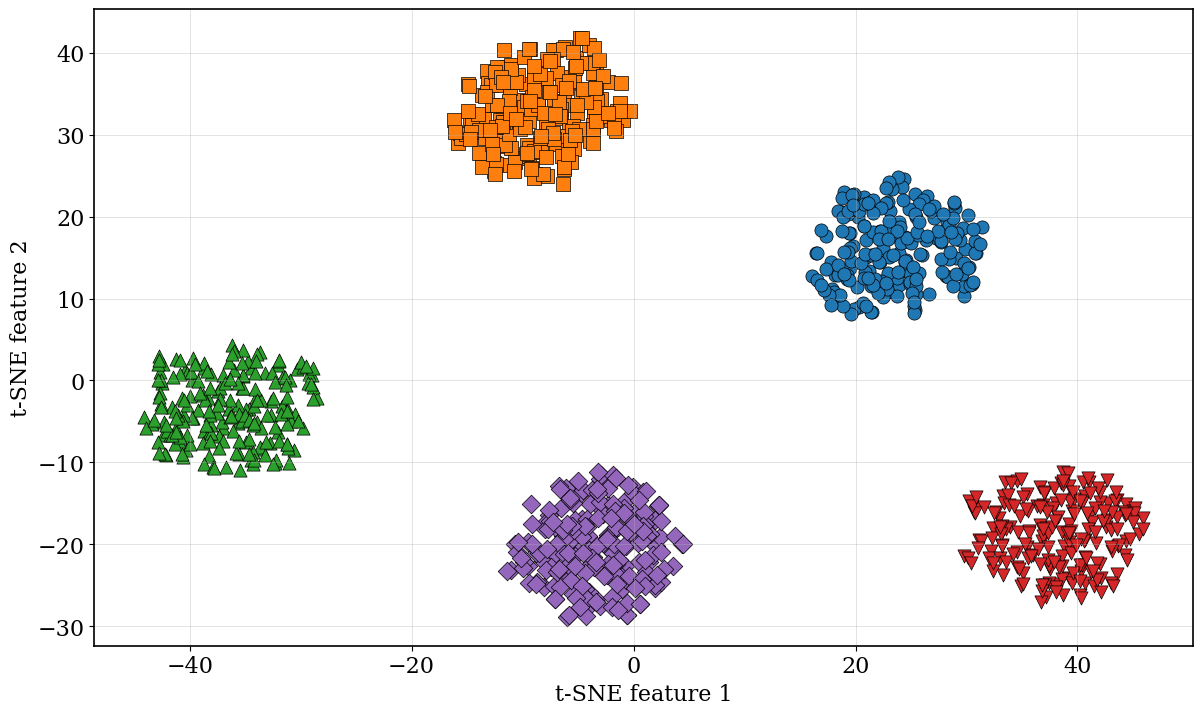

In [12]:
with mpl.rc_context(
    rc={
        "font.family": "serif",
        "font.serif": ["DejaVu Serif", "Liberation Serif", "Times", "serif"],  # Reliable serif fonts
        "mathtext.fontset": "dejavuserif",  # Use DejaVu for math text to avoid missing glyphs
        "axes.unicode_minus": False,  # Use ASCII minus instead of Unicode minus
        "font.size": 12,
        "axes.linewidth": 1.2,
        "axes.labelsize": 16,
        "axes.titlesize": 16,
        "xtick.labelsize": 16,
        "ytick.labelsize": 16,
        "legend.fontsize": 10,
        "legend.frameon": True,
        "legend.fancybox": False,
        "legend.shadow": False,
        "legend.framealpha": 0.9,
        "legend.edgecolor": "black",
        "grid.alpha": 0.5,
        "axes.grid": True,
        "grid.linewidth": 0.5,
    }
):
    cm = 1 / 2.54  # centimeters to inches
    fig_scale = 3.0
    fig, ax = plt.subplots(figsize=(12 * fig_scale * cm, 7 * fig_scale * cm))
    # Create discrete colormap with only the colors you need
    n_clusters = len(np.unique(labels))
    colors = plt.colormaps["tab10"].colors
    markers = ["o", "s", "^", "v", "D", "P", "*", "X", "p", "h"]  # circle, square, triangle, etc.
    for i, label in enumerate(unique_labels):
        mask = labels == label
        ax.scatter(
            X_embedded[mask, 0],
            X_embedded[mask, 1],
            c=[colors[i % len(colors)]],
            marker=markers[i % len(markers)],
            s=90,
            label=f"Cluster {label}",
            edgecolor="black",
            linewidth=0.5,
        )
    ax.set_ylabel("t-SNE feature 2")
    ax.set_xlabel("t-SNE feature 1")
    # ax.set_title(f"VertCoHiRF: ARI={ari:.3f}")
    fig.savefig(
        results_dir
        / f"hypercube_{model}_n-samples-{n_samples}_n-informative-{n_informative}_n-random-{n_random}_n-classes-{n_classes}.pdf",
        dpi=600,
        bbox_inches="tight",
    )

Combinations completed:   0%|          | 0/1 [00:00<?, ?it/s]

Trials:   0%|          | 0/50 [00:00<?, ?it/s]

Agent 0 - Best Adjusted Rand Index (ARI) from HPO: 0.37406015037593987


Combinations completed:   0%|          | 0/1 [00:00<?, ?it/s]

Combinations completed:   0%|          | 0/1 [00:00<?, ?it/s]

...

Combinations completed:   0%|          | 0/1 [00:00<?, ?it/s]

Combinations completed:   0%|          | 0/1 [00:00<?, ?it/s]

Trials:   0%|          | 0/50 [00:00<?, ?it/s]

Agent 2 - Best Adjusted Rand Index (ARI) from HPO: 0.37406015037593987


Combinations completed:   0%|          | 0/1 [00:00<?, ?it/s]

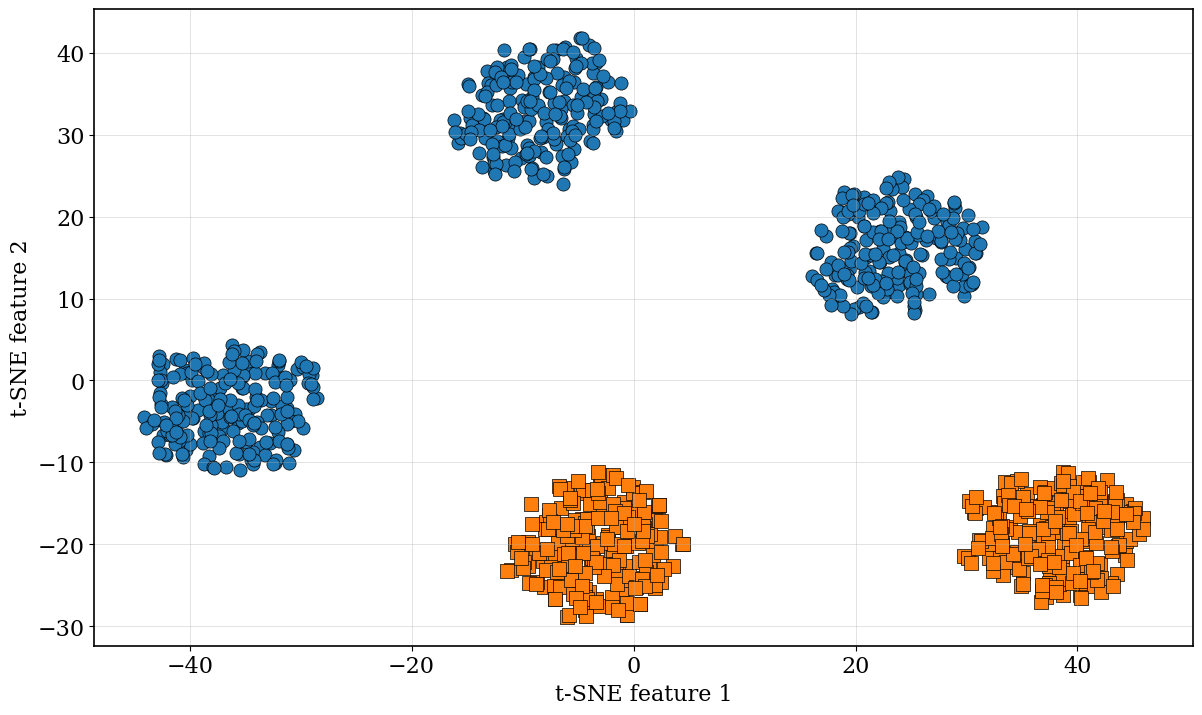

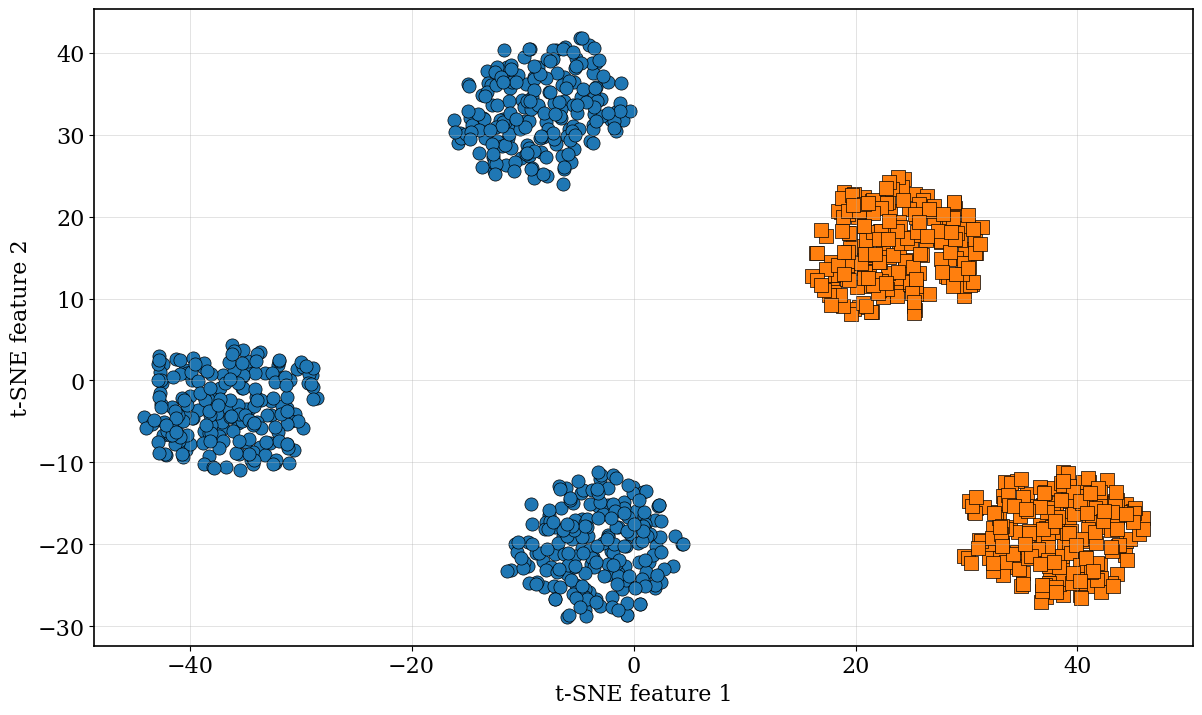

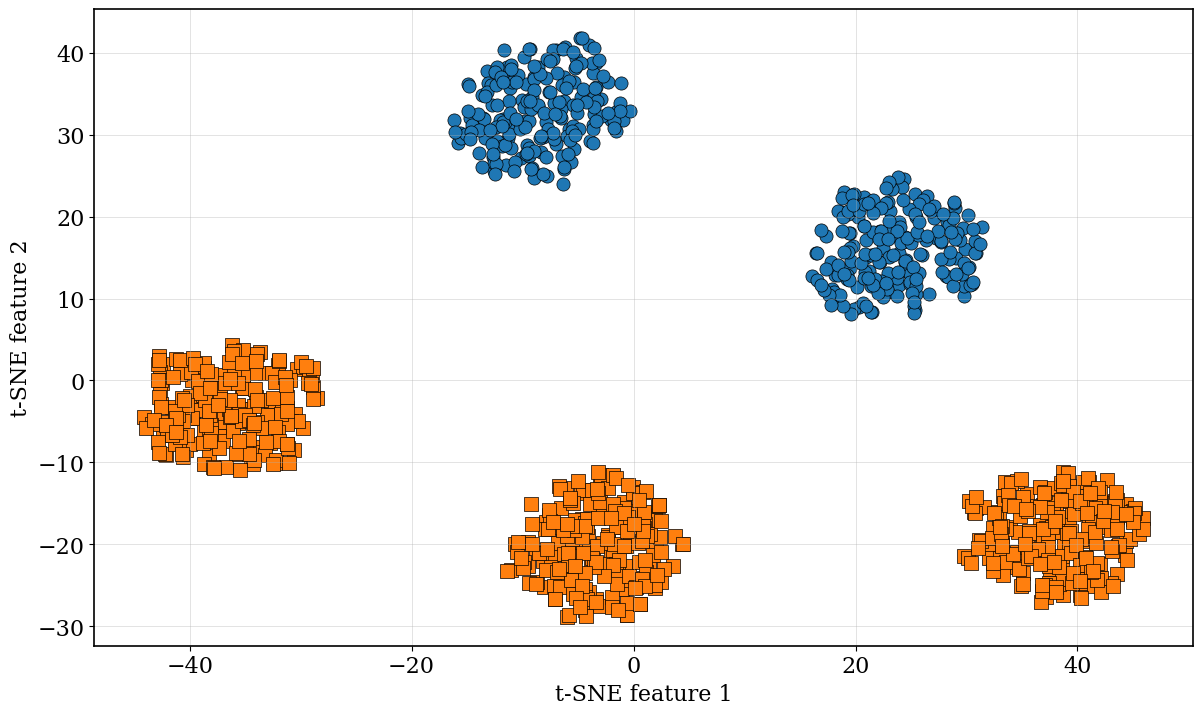

In [13]:
model = "CoHiRF"
agent_i = [i for i in range(n_agents)]
for ai in agent_i:
    hpo_experiment = HPOClassificationCoClusteringExperiment(
        agent_i=ai,
        # dataset
        n_samples=n_samples,
        n_informative=n_informative,
        n_random=n_random,
        n_redundant=n_redundant,
        n_repeated=n_repeated,
        n_classes=n_classes,
        class_sep=class_sep,
        seed_dataset=seed_dataset,
        shift=shift,
        scale=scale,
        n_agents=n_agents,
        p_overlap=p_overlap,
        sequential_split=sequential_split,
        features_groups=features_groups,
        # model
        model=model,
        n_trials=n_trials,
        # seed_model=seed_dataset,
        # hpo
        hpo_seed=seed_dataset,
        hpo_metric=hpo_metric,
        direction=direction,
        # experiment
        raise_on_error=True,
        verbose=1,
    )
    hpo_result = hpo_experiment.run(return_results=True)[0]
    ari = hpo_result["evaluate_model_return"]["best/adjusted_rand_mean"]
    print(f"Agent {ai} - Best Adjusted Rand Index (ARI) from HPO: {ari}")

    best_params = hpo_result["fit_model_return"]["study"].best_params
    best_params = unflatten_any(best_params)
    best_seed = hpo_result["fit_model_return"]["study"].best_trial.user_attrs["result"]["seed_model"]

    experiment = ClassificationCoClusteringExperiment(
        agent_i=ai,
        # dataset
        n_samples=n_samples,
        n_informative=n_informative,
        n_random=n_random,
        n_redundant=n_redundant,
        n_repeated=n_repeated,
        n_classes=n_classes,
        class_sep=class_sep,
        seed_dataset=seed_dataset,
        shift=shift,
        scale=scale,
        n_agents=n_agents,
        p_overlap=p_overlap,
        sequential_split=sequential_split,
        features_groups=features_groups,
        # model
        model=model,
        model_params=best_params,
        seed_model=best_seed,
        # experiment
        raise_on_error=True,
        verbose=1,
    )
    result = experiment.run(return_results=True)[0]
    features = result["load_data_return"]["X"]
    y_true = result["load_data_return"]["y"]
    labels = result["fit_model_return"]["y_pred"]
    unique_labels = np.unique(labels)
    tsne = TSNE(n_components=2, random_state=seed_dataset)
    X_embedded = tsne.fit_transform(features)
    with mpl.rc_context(
        rc={
            "font.family": "serif",
            "font.serif": ["DejaVu Serif", "Liberation Serif", "Times", "serif"],  # Reliable serif fonts
            "mathtext.fontset": "dejavuserif",  # Use DejaVu for math text to avoid missing glyphs
            "axes.unicode_minus": False,  # Use ASCII minus instead of Unicode minus
            "font.size": 12,
            "axes.linewidth": 1.2,
            "axes.labelsize": 16,
            "axes.titlesize": 16,
            "xtick.labelsize": 16,
            "ytick.labelsize": 16,
            "legend.fontsize": 10,
            "legend.frameon": True,
            "legend.fancybox": False,
            "legend.shadow": False,
            "legend.framealpha": 0.9,
            "legend.edgecolor": "black",
            "grid.alpha": 0.5,
            "axes.grid": True,
            "grid.linewidth": 0.5,
        }
    ):
        cm = 1 / 2.54  # centimeters to inches
        fig_scale = 3.0
        fig, ax = plt.subplots(figsize=(12 * fig_scale * cm, 7 * fig_scale * cm))
        # Create discrete colormap with only the colors you need
        n_clusters = len(np.unique(labels))
        colors = plt.colormaps["tab10"].colors
        markers = ["o", "s", "^", "v", "D", "P", "*", "X", "p", "h"]  # circle, square, triangle, etc.
        for i, label in enumerate(unique_labels):
            mask = labels == label
            ax.scatter(
                X_embedded[mask, 0],
                X_embedded[mask, 1],
                c=[colors[i % len(colors)]],
                marker=markers[i % len(markers)],
                s=90,
                label=f"Cluster {label}",
                edgecolor="black",
                linewidth=0.5,
            )
        ax.set_ylabel("t-SNE feature 2")
        ax.set_xlabel("t-SNE feature 1")
        fig.savefig(
            results_dir
            / f"hypercube_{model}_agent-{ai}_n-samples-{n_samples}_n-informative-{n_informative}_n-random-{n_random}_n-classes-{n_classes}.pdf",
            dpi=600,
            bbox_inches="tight",
        )